In [1]:
# 1. Imports and reproducibility

from pathlib import Path
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss,
    classification_report,
    confusion_matrix,
)

from xgboost import XGBClassifier
import xgboost

RANDOM_STATE = 42

print("Python:", platform.python_version())
print("Pandas:", pd.__version__)
print("XGBoost:", xgboost.__version__)

Python: 3.12.13
Pandas: 2.3.3
XGBoost: 3.2.0


In [3]:
# 2. Locate dataset files
from pathlib import Path
candidate_dirs = [
    Path("/kaggle/input/datasets/faiyazbinkhaled33/nbadataset"),
    Path("/kaggle/input/uts-36120-26-sp"),
]

data_dir = next(
    (p for p in candidate_dirs if (p / "train.csv").exists()),
    None
)

# Fallback: search Kaggle input recursively
if data_dir is None and Path("/kaggle/input").exists():
    matches = list(Path("/kaggle/input").rglob("train.csv"))
    if matches:
        data_dir = matches[0].parent

if data_dir is None:
    raise FileNotFoundError(
        "Could not find train.csv. Attach the competition dataset to the notebook."
    )

print("Using data directory:", data_dir)

train_path = data_dir / "train.csv"
test_path = data_dir / "test.csv"
sample_path = data_dir / "sample_submission.csv"
metadata_path = data_dir / "metadata.csv"

train = pd.read_csv(train_path, low_memory=False)
test = pd.read_csv(test_path, low_memory=False)
sample_submission = pd.read_csv(sample_path)

metadata = None

if metadata_path.exists():
    metadata = pd.read_csv(
        metadata_path,
        encoding="latin1"
    )

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)

train.head()

Using data directory: /kaggle/input/datasets/faiyazbinkhaled33/nbadataset
Train shape: (41195, 66)
Test shape: (12061, 65)
Sample submission shape: (12061, 2)


,team,conf,GP,Min_per,ORtg,usg,eFG,TS_per,ORB_per,DRB_per,...,dreb,treb,ast,stl,blk,pts,role,3p/100?,dob,label
0,Detroit Mercy,Horz,6,1.0,0.0,16.8,0.0,0.00,0.0,11.4,...,0.1429,0.2857,0.0000,0.2857,0.0000,0.0000,NaN,5.70546,1987-10-15,0
1,South Alabama,SB,22,8.4,62.0,14.1,32.6,33.40,0.0,5.4,...,0.3333,0.3333,0.2083,0.0833,0.0000,0.7500,NaN,6.20657,1989-05-19,0
2,Utah St.,WAC,28,24.3,93.1,13.8,45.2,46.20,1.4,6.6,...,0.6897,0.8276,1.0000,0.3793,0.0690,2.4483,NaN,4.26818,1988-07-01,0
3,Arizona,P10,6,1.0,15.8,18.4,0.0,0.00,9.7,0.0,...,0.0000,0.1667,0.0000,0.0000,0.1667,0.0000,NaN,4.60267,1986-10-15,0
4,South Florida,BE,30,71.1,105.8,19.0,50.6,54.16,2.3,8.4,...,2.2333,2.8333,2.6333,0.5667,0.0667,10.7000,NaN,7.81267,1986-10-15,0


,count,percentage
label,,
0,39785,96.58
1,1410,3.42


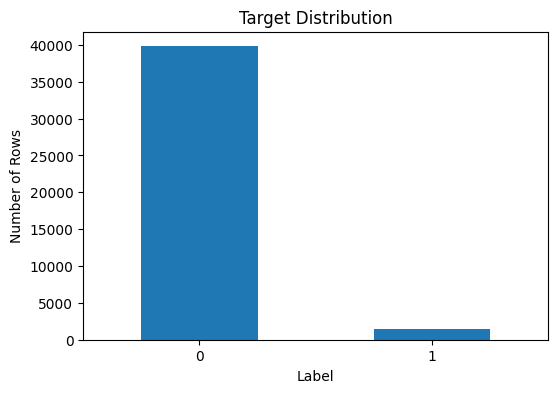

In [4]:
# 3. Target distribution

target_counts = train["label"].value_counts().sort_index()
target_percent = train["label"].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percent.round(2)
})

display(target_summary)

plt.figure(figsize=(6, 4))
target_counts.plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("Label")
plt.ylabel("Number of Rows")
plt.xticks(rotation=0)
plt.show()

In [5]:
# 4. Exact duplicates

print("Shape before duplicate removal:", train.shape)
print("Exact duplicate rows:", train.duplicated().sum())

train = train.drop_duplicates().reset_index(drop=True)

print("Shape after duplicate removal:", train.shape)
print("Duplicates remaining:", train.duplicated().sum())

Shape before duplicate removal: (41195, 66)
Exact duplicate rows: 3481
Shape after duplicate removal: (37714, 66)
Duplicates remaining: 0


,missing_count,missing_percent
Rec Rank,26002,68.95
dunksmade/(dunksmade+dunksmiss),23951,63.51
type,16257,43.11
rimmade/(rimmade+rimmiss),11720,31.08
midmade/(midmade+midmiss),11694,31.01
rimmade+rimmiss,9843,26.10
midmade+midmiss,9843,26.10
dunksmade,9843,26.10
midmade,9843,26.10
rimmade,9843,26.10


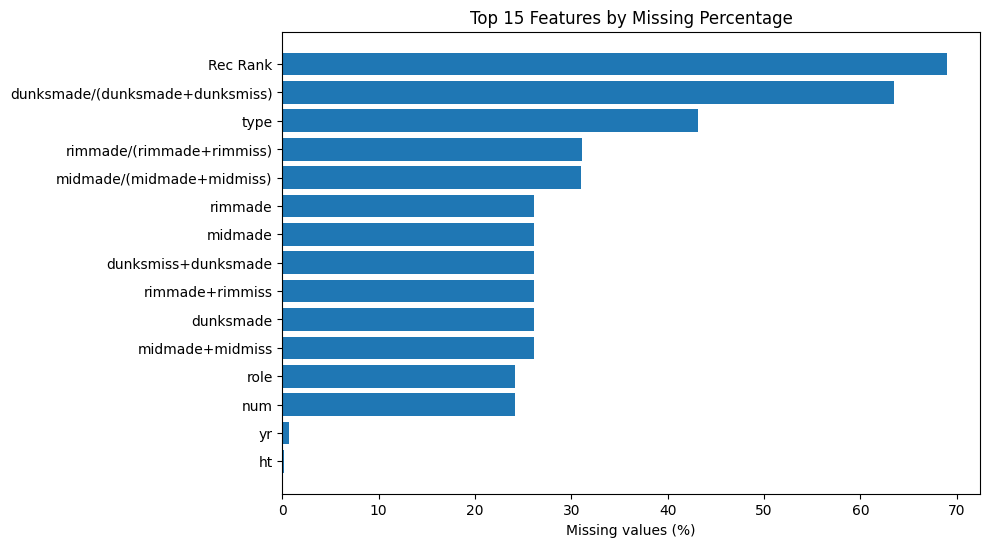

In [6]:
# 5. Missing-value summary

missing_summary = pd.DataFrame({
    "missing_count": train.isna().sum(),
    "missing_percent": (train.isna().mean() * 100).round(2)
})

missing_summary = (
    missing_summary[missing_summary["missing_count"] > 0]
    .sort_values("missing_percent", ascending=False)
)

display(missing_summary.head(20))

top_missing = missing_summary.head(15).sort_values("missing_percent")

plt.figure(figsize=(9, 6))
plt.barh(top_missing.index, top_missing["missing_percent"])
plt.xlabel("Missing values (%)")
plt.title("Top 15 Features by Missing Percentage")
plt.show()

In [7]:
# 6. Save IDs, features and target

train_pid = train["pid"].copy()
test_pid = test["pid"].copy()

y = train["label"].copy()

X = train.drop(columns=["label", "pid"]).copy()
X_test = test.drop(columns=["pid"]).copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_test shape:", X_test.shape)

X shape: (37714, 64)
y shape: (37714,)
X_test shape: (12061, 64)


In [8]:
# 7. Feature engineering function

def engineer_features(df):
    df = df.copy()

    # Convert height such as "6-7" to total inches
    def height_to_inches(value):
        try:
            feet, inches = str(value).split("-")
            return int(feet) * 12 + int(inches)
        except (ValueError, TypeError):
            return np.nan

    if "ht" in df.columns:
        df["height_inches"] = df["ht"].apply(height_to_inches)
        df.drop(columns=["ht"], inplace=True)

    # Convert date of birth to approximate age in that season
    if "dob" in df.columns:
        dob = pd.to_datetime(df["dob"], errors="coerce")
        df["age"] = df["year"] - dob.dt.year

        # Remove clearly implausible ages
        df.loc[(df["age"] < 15) | (df["age"] > 30), "age"] = np.nan

        df.drop(columns=["dob"], inplace=True)

    # Baseline exclusions
    df.drop(columns=["num", "type"], errors="ignore", inplace=True)

    # Replace infinities from ratio features with missing values
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    return df


X = engineer_features(X)
X_test = engineer_features(X_test)

print("Engineered training shape:", X.shape)
print("Engineered test shape:", X_test.shape)

print(
    "Train/test columns identical:",
    list(X.columns) == list(X_test.columns)
)

Engineered training shape: (37714, 62)
Engineered test shape: (12061, 62)
Train/test columns identical: True


In [9]:
# 8. Identify categorical and numerical columns

categorical_cols = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_cols = X.select_dtypes(
    include=np.number
).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumber of categorical columns:", len(categorical_cols))
print("Number of numerical columns:", len(numeric_cols))

# Safety check
assert set(categorical_cols + numeric_cols) == set(X.columns)

Categorical columns:
['team', 'conf', 'yr', 'role']

Number of categorical columns: 4
Number of numerical columns: 58


In [10]:
# 9. Grouped train/validation split

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

train_idx, val_idx = next(
    splitter.split(X, y, groups=train_pid)
)

X_train = X.iloc[train_idx].copy()
X_val = X.iloc[val_idx].copy()

y_train = y.iloc[train_idx].copy()
y_val = y.iloc[val_idx].copy()

print("Training rows:", len(X_train))
print("Validation rows:", len(X_val))

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).sort_index().round(4))

print("\nValidation target distribution:")
print(y_val.value_counts(normalize=True).sort_index().round(4))

Training rows: 30065
Validation rows: 7649

Training target distribution:
label
0    0.9663
1    0.0337
Name: proportion, dtype: float64

Validation target distribution:
label
0    0.9663
1    0.0337
Name: proportion, dtype: float64


In [12]:
# 11. Preprocessing definition

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="Missing"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [13]:
# 12. Calculate class imbalance from the training split

negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())

scale_pos_weight = negative_count / positive_count

print("Negative training examples:", negative_count)
print("Positive training examples:", positive_count)
print("scale_pos_weight:", round(scale_pos_weight, 3))

Negative training examples: 29052
Positive training examples: 1013
scale_pos_weight: 28.679


## 9. XGBoost experiments

Three configurations are evaluated using exactly the same grouped validation set.

### Experiment 1 — Baseline
A straightforward XGBoost model with moderate tree depth.

### Experiment 2 — Weighted
The baseline is repeated using `scale_pos_weight`.

### Experiment 3 — Tuned
Uses shallower trees, a lower learning rate, more estimators, and additional regularisation.

### Metrics

- **ROC-AUC:** ranking quality across thresholds;
- **PR-AUC / Average Precision:** particularly informative for the rare positive class;
- **Log Loss:** quality of predicted probabilities.

This notebook selects the final configuration using **ROC-AUC**. If the competition Evaluation page specifies a different official metric, use that official metric when making the final competition decision.

In [14]:
# 13. Helper for building an XGBoost pipeline

def build_xgb_pipeline(model_params):
    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist",
        **model_params
    )

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", model)
        ]
    )

In [15]:
# 14. Define XGBoost experiments

experiment_configs = {
    "XGB Baseline": {
        "n_estimators": 500,
        "max_depth": 5,
        "learning_rate": 0.05,
        "subsample": 0.80,
        "colsample_bytree": 0.80,
        "scale_pos_weight": 1.0,
    },

    "XGB Weighted": {
        "n_estimators": 500,
        "max_depth": 5,
        "learning_rate": 0.05,
        "subsample": 0.80,
        "colsample_bytree": 0.80,
        "scale_pos_weight": scale_pos_weight,
    },

    "XGB Tuned": {
        "n_estimators": 800,
        "max_depth": 3,
        "learning_rate": 0.03,
        "subsample": 0.90,
        "colsample_bytree": 0.90,
        "min_child_weight": 5,
        "reg_lambda": 2.0,
        "scale_pos_weight": 1.0,
    },
}

experiment_configs

{'XGB Baseline': {'n_estimators': 500,
  'max_depth': 5,
  'learning_rate': 0.05,
  'subsample': 0.8,
  'colsample_bytree': 0.8,
  'scale_pos_weight': 1.0},
 'XGB Weighted': {'n_estimators': 500,
  'max_depth': 5,
  'learning_rate': 0.05,
  'subsample': 0.8,
  'colsample_bytree': 0.8,
  'scale_pos_weight': 28.679170779861796},
 'XGB Tuned': {'n_estimators': 800,
  'max_depth': 3,
  'learning_rate': 0.03,
  'subsample': 0.9,
  'colsample_bytree': 0.9,
  'min_child_weight': 5,
  'reg_lambda': 2.0,
  'scale_pos_weight': 1.0}}

In [16]:
# 15. Train and evaluate all experiments

experiment_results = []
trained_models = {}

for experiment_name, params in experiment_configs.items():
    print(f"Training: {experiment_name}")

    current_model = build_xgb_pipeline(params)
    current_model.fit(X_train, y_train)

    val_prob = current_model.predict_proba(X_val)[:, 1]

    roc_auc = roc_auc_score(y_val, val_prob)
    pr_auc = average_precision_score(y_val, val_prob)
    ll = log_loss(y_val, val_prob)

    experiment_results.append({
        "Experiment": experiment_name,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "Log Loss": ll,
    })

    trained_models[experiment_name] = current_model

    print(
        f"  ROC-AUC: {roc_auc:.6f} | "
        f"PR-AUC: {pr_auc:.6f} | "
        f"Log Loss: {ll:.6f}"
    )
    print("-" * 70)

results_df = pd.DataFrame(experiment_results)
results_df = results_df.sort_values(
    "ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(results_df)

Training: XGB Baseline
  ROC-AUC: 0.874736 | PR-AUC: 0.445289 | Log Loss: 0.100101
----------------------------------------------------------------------
Training: XGB Weighted
  ROC-AUC: 0.864584 | PR-AUC: 0.415476 | Log Loss: 0.174395
----------------------------------------------------------------------
Training: XGB Tuned
  ROC-AUC: 0.882246 | PR-AUC: 0.464468 | Log Loss: 0.096133
----------------------------------------------------------------------


,Experiment,ROC-AUC,PR-AUC,Log Loss
0,XGB Tuned,0.882246,0.464468,0.096133
1,XGB Baseline,0.874736,0.445289,0.100101
2,XGB Weighted,0.864584,0.415476,0.174395


In [ ]:
# 16. Visual comparison of experiments

plot_df = results_df.sort_values("ROC-AUC")

plt.figure(figsize=(8, 4))
plt.barh(plot_df["Experiment"], plot_df["ROC-AUC"])
plt.xlabel("ROC-AUC")
plt.title("XGBoost Experiment Comparison")
plt.show()

## 10. Select the best validation model

The best configuration is chosen using ROC-AUC.

PR-AUC and Log Loss are still displayed because they describe different aspects of performance.

In [17]:
# 17. Select best validation model

best_experiment = results_df.iloc[0]["Experiment"]
best_validation_model = trained_models[best_experiment]

print("Best experiment:", best_experiment)
print("Best ROC-AUC:", round(results_df.iloc[0]["ROC-AUC"], 6))
print("PR-AUC:", round(results_df.iloc[0]["PR-AUC"], 6))
print("Log Loss:", round(results_df.iloc[0]["Log Loss"], 6))

Best experiment: XGB Tuned
Best ROC-AUC: 0.882246
PR-AUC: 0.464468
Log Loss: 0.096133


In [18]:
# 18. Optional threshold-based diagnostic

# These threshold metrics are not used to choose the probability model.
best_val_prob = best_validation_model.predict_proba(X_val)[:, 1]
best_val_pred = (best_val_prob >= 0.50).astype(int)

print("Confusion matrix at threshold = 0.50")
print(confusion_matrix(y_val, best_val_pred))

print("\nClassification report at threshold = 0.50")
print(
    classification_report(
        y_val,
        best_val_pred,
        digits=4,
        zero_division=0
    )
)

Confusion matrix at threshold = 0.50
[[7372   19]
 [ 202   56]]

Classification report at threshold = 0.50
              precision    recall  f1-score   support

           0     0.9733    0.9974    0.9852      7391
           1     0.7467    0.2171    0.3363       258

    accuracy                         0.9711      7649
   macro avg     0.8600    0.6072    0.6608      7649
weighted avg     0.9657    0.9711    0.9633      7649



## 11. Feature importance

XGBoost feature importance gives an indication of which transformed inputs contributed most strongly to the model.

Because categorical variables are one-hot encoded, some feature names represent individual category levels.

,feature,importance
0,bpm,0.142584
1,dporpag,0.136388
2,yr_Sr,0.060647
3,gbpm,0.040113
4,Rec Rank,0.031165
5,twoPA,0.022717
6,age,0.020563
7,yr_Fr,0.019707
8,blk,0.013572
9,porpag,0.012877


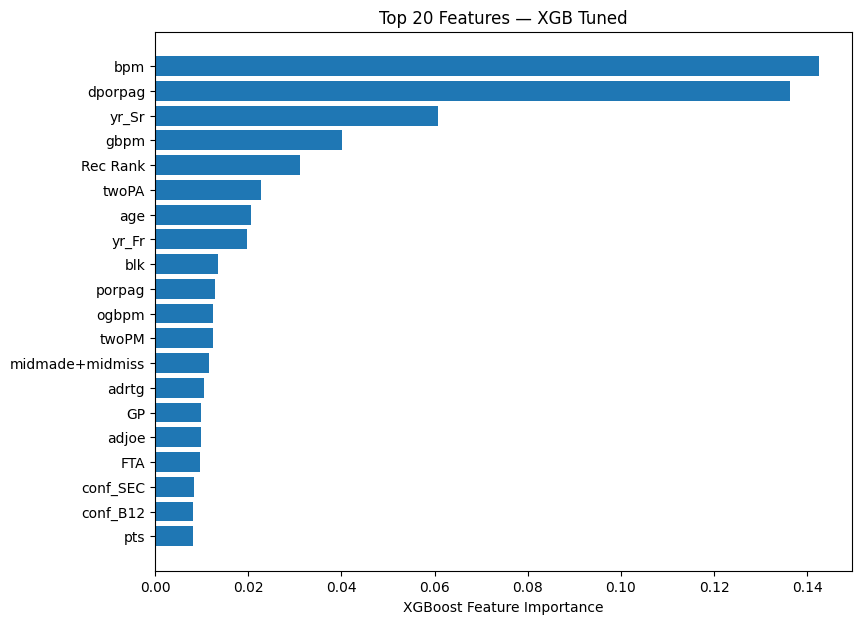

In [19]:
# 19. Feature importance from the best validation model

fitted_preprocessor = best_validation_model.named_steps["preprocessor"]
fitted_classifier = best_validation_model.named_steps["classifier"]

feature_names = fitted_preprocessor.get_feature_names_out()
feature_importances = fitted_classifier.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": feature_importances
})

importance_df["feature"] = (
    importance_df["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

display(importance_df.head(20))

top_features = importance_df.head(20).sort_values("importance")

plt.figure(figsize=(9, 7))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("XGBoost Feature Importance")
plt.title(f"Top 20 Features — {best_experiment}")
plt.show()

## 12. Retrain the selected XGBoost configuration on all training data

The validation set was held out only for model comparison.

After selecting the best configuration, the final model is fitted using all available cleaned training rows before predicting the Kaggle test set.

In [20]:
# 20. Build final model parameters

best_params = experiment_configs[best_experiment].copy()

# If a weighted experiment wins, recalculate its weight using all training data
if best_params.get("scale_pos_weight", 1.0) != 1.0:
    full_negative = int((y == 0).sum())
    full_positive = int((y == 1).sum())
    best_params["scale_pos_weight"] = full_negative / full_positive

print("Final experiment:", best_experiment)
print("Final parameters:")

for key, value in best_params.items():
    print(f"  {key}: {value}")

Final experiment: XGB Tuned
Final parameters:
  n_estimators: 800
  max_depth: 3
  learning_rate: 0.03
  subsample: 0.9
  colsample_bytree: 0.9
  min_child_weight: 5
  reg_lambda: 2.0
  scale_pos_weight: 1.0


In [22]:
# 21. Fit final model using all cleaned training data

final_model = build_xgb_pipeline(best_params)
final_model.fit(X, y)

print("Final XGBoost model fitted successfully.")

Final XGBoost model fitted successfully.


## 13. Generate Kaggle predictions

`predict_proba(... )[:, 1]` returns the estimated probability that `label = 1`.

The probabilities are submitted directly instead of converting them to 0/1.

In [23]:
# 22. Predict the test set

test_predictions = final_model.predict_proba(X_test)[:, 1]

prediction_summary = pd.Series(
    test_predictions,
    name="predicted_probability"
).describe()

display(prediction_summary)

print("Minimum probability:", test_predictions.min())
print("Maximum probability:", test_predictions.max())

assert np.all(test_predictions >= 0)
assert np.all(test_predictions <= 1)
assert np.isfinite(test_predictions).all()

count    12061.000000
mean         0.029838
std          0.090175
min          0.000261
25%          0.005003
50%          0.008355
75%          0.015813
max          0.985046
Name: predicted_probability, dtype: float64

Minimum probability: 0.00026141453
Maximum probability: 0.98504585


In [26]:
# 23. Create submission using the official sample file

submission = sample_submission.copy()

if len(submission) != len(test_predictions):
    raise ValueError(
        "Submission row count does not match the test predictions."
    )

if "pid" in submission.columns:
    same_ids = np.array_equal(
        submission["pid"].to_numpy(),
        test_pid.to_numpy()
    )
    print("Sample submission PID order matches test.csv:", same_ids)

submission["label"] = test_predictions

print("Submission shape:", submission.shape)
display(submission.head(10))

print("\nMissing submission values:")
print(submission.isna().sum())

Sample submission PID order matches test.csv: True
Submission shape: (12061, 2)


,pid,label
0,27085,0.003881
1,30747,0.011786
2,32932,0.009851
3,33635,0.094164
4,33955,0.314983
5,33978,0.008407
6,35307,0.022159
7,35623,0.029306
8,36023,0.012069
9,36331,0.001949



Missing submission values:
pid      0
label    0
dtype: int64


In [27]:
# 24. Save submission and experiment results

output_dir = (
    Path("/kaggle/working")
    if Path("/kaggle/working").exists()
    else Path(".")
)

submission_path = output_dir / "submission_xgboost.csv"
results_path = output_dir / "xgboost_experiment_results.csv"

submission.to_csv(submission_path, index=False)
results_df.to_csv(results_path, index=False)

print("Saved submission to:")
print(submission_path)

print("\nSaved experiment results to:")
print(results_path)

Saved submission to:
/kaggle/working/submission_xgboost.csv

Saved experiment results to:
/kaggle/working/xgboost_experiment_results.csv
